# Stage 3 — Hydrological Connectivity (Mole Creek prototype)

Answers a different question from Stage 2: not "where is karst?" but "where could something happening at the surface reach the karst?"

**Inputs:**
- `KPROXCATCH` — Karst Atlas field for proximal (allogenic) catchments draining directly into karst. Its A-D values classify *the karst area it drains into*, not the connectivity strength of the catchment itself, so it is treated as presence/absence, not an ordinal score.
- `KDISTCATCH` — distal catchments (whole upstream river catchment), scored lower (less direct effect, per the data dictionary).
- DEM-derived flow accumulation (WhiteboxTools) — an independent physical check against the Atlas classification.
- The exposure type from Stage 2.

**Scoring** (see `src/karst.py`): exposed = 3, covered = 2, interstratal = 1. Covered karst has a protective non-karst cap between the surface and the karst. EPIK's Protective Cover (P) factor treats that cover as reducing vulnerability, so covered scores below exposed. Interstratal karst is not autogenic at all per the data dictionary, since its recharge depends on an external catchment.

**Boundary:** the Mole Creek study boundary (Stage 0) is buffered by 3 km, because the unbuffered union of karst polygons was 99.9997% covered by karst/catchment features, leaving no surrounding land.

In [1]:
from pathlib import Path
import os
import sys
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import add_connectivity, rasterize_max
from mapping import add_attribution, add_basemap, data_bounds, finish_map, plot_scores, raster_extent, scores_legend

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

# Reads Stage 2's output, not Stage 1's -- each stage now has its own file
karst_mc = gpd.read_file(str(outpath / "karst_mc_susceptibility_EPSG7855.gpkg"))
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

## 3.1 Atlas-based connectivity score

Combines three signals via `add_connectivity()`, taking the **max** per
polygon (a polygon can be karst itself *and* separately flagged as a
catchment for an adjacent karst area — confirmed in the real data).

In [2]:
add_connectivity(karst_mc)

print("Connectivity score distribution (polygon count):")
print(karst_mc["connectivity"].value_counts().sort_index())
print()
print("Which component drove each score, by exposure type:")
print(pd.crosstab(karst_mc["connectivity"], karst_mc["exposure_type"]))

karst_mc.to_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg", driver="GPKG")

Connectivity score distribution (polygon count):
connectivity
0     5
2    18
3    67
Name: count, dtype: int64

Which component drove each score, by exposure type:
exposure_type  covered  exposed  interstratal  non-karst
connectivity                                            
0                    0        0             0          5
2                   18        0             0          0
3                    0       45            10         12


## 3.2 Rasterise onto the Stage 1 DEM template

Any cell not covered by a karst/catchment polygon at all correctly falls back to 0 (real background land, now that the boundary includes it). Uses `rasterize_max()` -- see Stage 2's note on why.

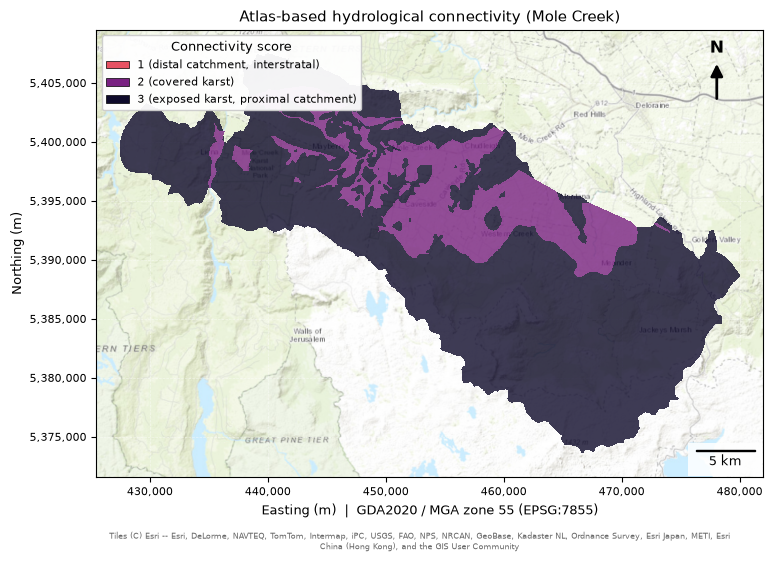

In [3]:
with rasterio.open(str(outpath / "dem_mc_EPSG7855.tif")) as dem_src:
    template_transform = dem_src.transform
    template_shape = (dem_src.height, dem_src.width)
    template_crs = dem_src.crs

connectivity_raster = rasterize_max(karst_mc, "connectivity", template_shape, template_transform)

profile = {
    "driver": "GTiff", "height": template_shape[0], "width": template_shape[1],
    "count": 1, "dtype": "uint8", "crs": template_crs, "transform": template_transform, "nodata": 255,
}
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif", "w", **profile) as dst:
    dst.write(connectivity_raster, 1)

CONNECTIVITY_LABELS = ["None", "1 (distal catchment, interstratal)", "2 (covered karst)", "3 (exposed karst, proximal catchment)"]
bounds = data_bounds(connectivity_raster > 0, template_transform)
fig, ax = plt.subplots(figsize=(10, 5.6))
add_basemap(ax, bounds, zoom=11)
plot_scores(ax, connectivity_raster, template_transform, 4)
scores_legend(ax, CONNECTIVITY_LABELS, title="Connectivity score")
ax.set_title("Atlas-based hydrological connectivity (Mole Creek)", fontsize=11)
finish_map(ax)
add_attribution(ax)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## Stage 3 outputs

- `connectivity_atlas_mc_EPSG7855.tif` — Atlas-based connectivity raster (0-3)
- `karst_mc_connectivity_EPSG7855.gpkg` — Stage 2's data plus connectivity columns (the complete Mole Creek karst vector used by Stages 4, 6, and 8)

**Limitation:** the three-layer framework in the scope doc treats karst susceptibility, hydrological connectivity and land-use pressure as three independent factors. At Mole Creek, connectivity is close to a binary mask (most karst polygons score the maximum); see Stage 4. Statewide (Stage 7), connectivity varies, since not every karst area has a proximal catchment tagged.

**On the DEM-derived channel-network check (removed here):** earlier versions of this notebook compared DEM-derived flow accumulation against the Atlas connectivity classes as a plausibility check (a weak, non-contradictory signal: roughly 4-5% channel-cell density in every connectivity class). That block wrote `flow_accum_mc_EPSG7855.tif` and `dem_mc_pointer.tif`, which no downstream notebook (00-14) ever reads — it was a self-contained side-check, not part of the score. It has been removed here because a substantially more rigorous version of the same check now exists on the `connectivity-hydlines` branch (`03alt`, `03alt2`, `03alt3`): real D8 upstream flow-routing to each karst target (not a flow-accumulation threshold), validated against mapped watercourses with precision/recall/F1/IoU, at both 2 m and 25 m resolution. See that branch, and `notebooks/13_connectivity_v2.ipynb`, for the current connectivity-v2 work.

**Next (Stage 4):** combine Stage 2 (susceptibility) × Stage 3 (connectivity) into intrinsic karst vulnerability, still at the Mole Creek prototype stage, before Stage 5 introduces land-use pressure.
